In [50]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
class Value:
    def __init__(self, data, _children=(), _op='',label=''):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self.label=label
        self.grad=0.0
        self._backward=lambda:None
        
   
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),"+")
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self*other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x=self.data
        y=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(y,(self,),'tanh')

        def _backward():
            self.grad+=(1-y**2)*out.grad
        out._backward=_backward
        return out
    
    def backward(self):
        topo=[]
        vis=set()
 
        def build_topo(v):
            if v not in vis:
                vis.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
    
        self.grad=1.0
        build_topo(self)
        for node in reversed(topo):
           node._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [52]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s |data %.4f|grad %.4f}" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


In [53]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
t=x1w1+x2w2;t.label='t'
n=t+b;n.label='n'
o=n.tanh();o.label='o'

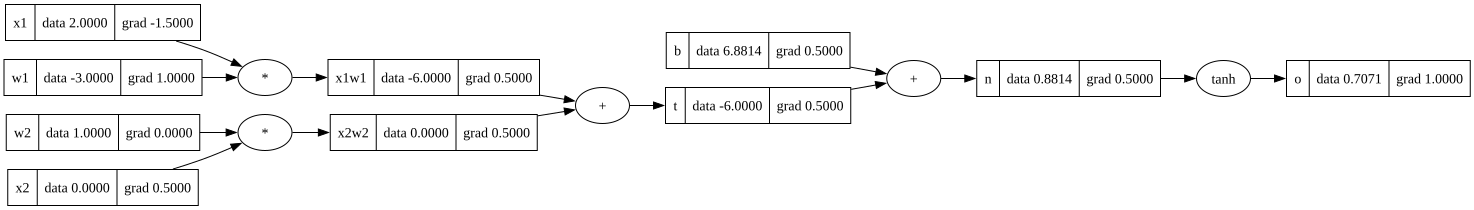

In [54]:
o.backward()
draw_dot(o)


In [55]:
import torch
x1=torch.tensor([2.0]).double();x1.requires_grad=True
x2=torch.tensor([0.0]).double();x2.requires_grad=True
w1=torch.tensor([-3.0]).double();w1.requires_grad=True
w2=torch.tensor([1.0]).double();w2.requires_grad=True
b=torch.tensor([6.8813735870195432]).double();b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print("---------")
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('w1',w1.grad.item())
print('x1',x1.grad.item())




0.7071066904050358
---------
x2 0.5000001283844369
w2 0.0
w1 1.0000002567688737
x1 -1.5000003851533106


In [56]:
import random
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    
    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    def parameters(self):
        return self.w+[self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs=[n(x) for n in self.neurons]
        return outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    

class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)


[Value(data=-0.6867265354916929, grad=0.0)]

In [57]:
'''
return [p for neuron in self.neurons for p in neuron.parameters()] 等价于：
result=[]

for neuron in self.neurons:
  for p in neuron.parameters():
   result.append(p)
'''

'\nreturn [p for neuron in self.neurons for p in neuron.parameters()] 等价于：\nresult=[]\n\nfor neuron in self.neurons:\n  for p in neuron.parameters():\n   result.append(p)\n'

In [58]:
''' 假设MLP(3,[4,4,1]) 3输入,1输出
def __init__(self, nin, nouts):
    sz = [nin] + nouts   # 把输入维度拼到最前面
    sz = [3, 4, 4, 1]     ← 每一层的输入维度
          ↑  ↑  ↑  ↑
        第0层 第1层 第2层 第3层(没有)

    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
                  ↑ 输入维度  ↑ 输出维度
    self.layer=[Layer(3,4),Layer(4,4),Layer(4,1)]
'''

' 假设MLP(3,[4,4,1]) 3输入,1输出\ndef __init__(self, nin, nouts):\n    sz = [nin] + nouts   # 把输入维度拼到最前面\n    sz = [3, 4, 4, 1]     ← 每一层的输入维度\n          ↑  ↑  ↑  ↑\n        第0层 第1层 第2层 第3层(没有)\n\n    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]\n                  ↑ 输入维度  ↑ 输出维度\n    self.layer=[Layer(3,4),Layer(4,4),Layer(4,1)]\n'

In [59]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [1.0,1.0,-1.0],
]

ys=[1.0,-1.0,-1.0,1.0]

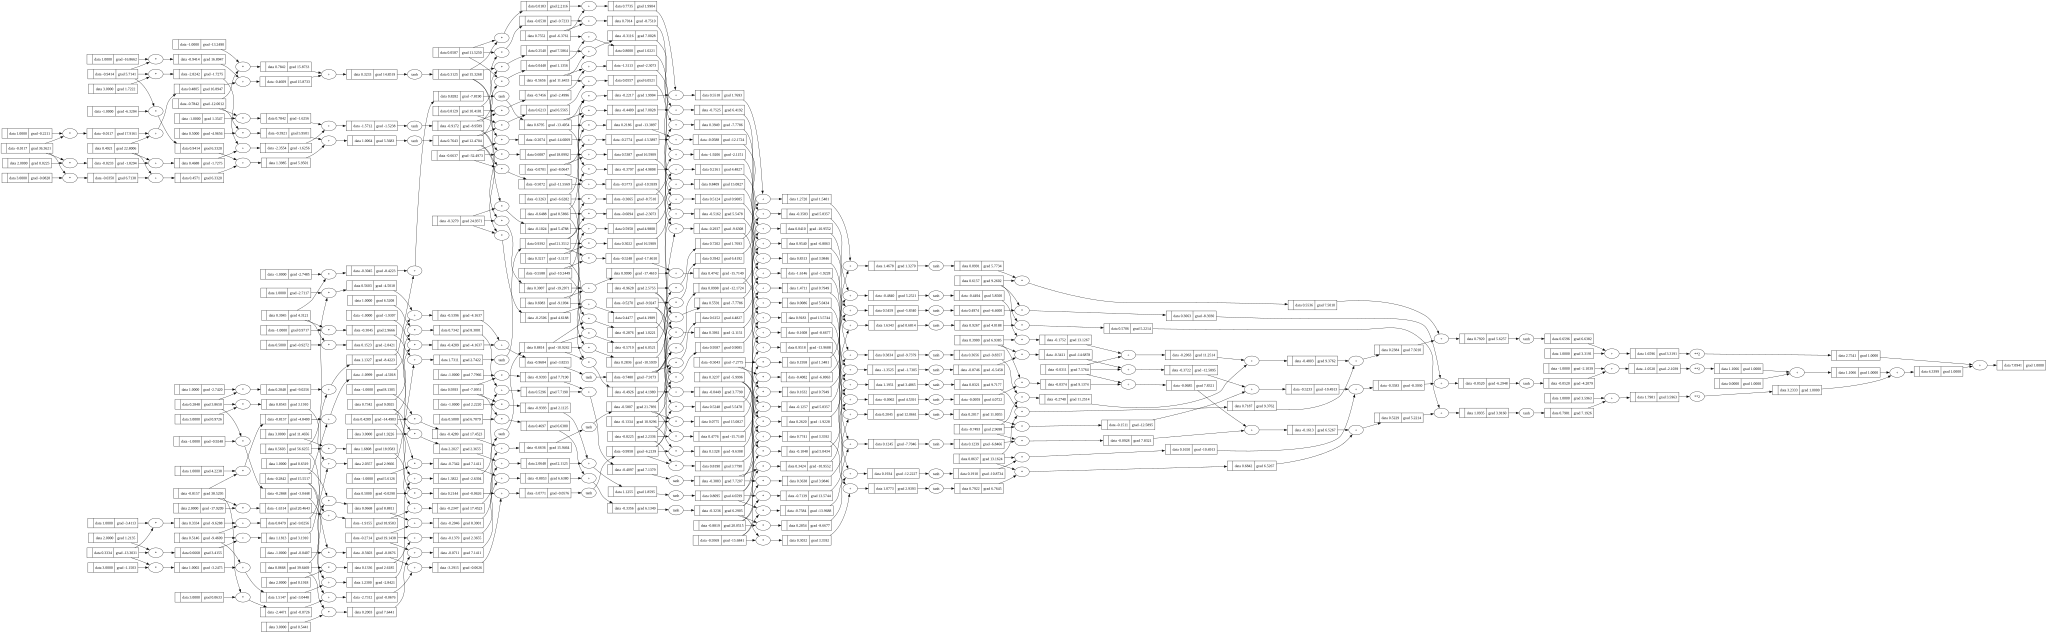

In [60]:
loss=sum([(yout[0]-ygt)**2 for ygt, yout in zip(ys, ypred)])
loss
loss.backward()
draw_dot(loss)

In [67]:
for k in range(20):
    #forward pass
    ypred=[n(x) for x in xs]
    loss=sum([(yout[0]-ygt)**2 for ygt, yout in zip(ys, ypred)])

    #backward pass
    for p in n.parameters():
        p.grad=0.0
    
    loss.backward()

    #update
    for p in n.parameters():
        p.data+=-0.10*p.grad

    print(k,loss.data)

0 0.0027306720367007205
1 0.002701998204578754
2 0.0026738911444669023
3 0.0026463345768926866
4 0.0026193128321189084
5 0.0025928108221010774
6 0.002566814013969138
7 0.002541308404937828
8 0.0025162804985574723
9 0.002491717282222434
10 0.0024676062058608104
11 0.002443935161733829
12 0.0024206924652784506
13 0.0023978668369310984
14 0.0023754473848748656
15 0.0023534235886557564
16 0.002331785283617993
17 0.002310522646110952
18 0.0022896261794237358
19 0.0022690867004061975
